# VAE Workflow (Organized)
This notebook is organized into: imports, data loading, base config, base run, experiments, ablation table, final training, metrics visualization, and model loading for generation.

In [1]:
# 1) Imports
%load_ext autoreload
%autoreload 2

import os
import sys

sys.path.append(os.path.abspath(".."))

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import DataLoader

from src.data.dataset import FacesDataset
from src.data.transforms import get_test_transform, get_train_transform
from src.models.vae import VAE
from src.utils.vae_utils import evaluate_vae, generate_vae_samples, train_vae_full

In [2]:
# 2) Data loading
device = "cuda" if torch.cuda.is_available() else "cpu"

# Resolve project root robustly (works whether cwd is project root or notebooks/)
PROJECT_ROOT = os.path.abspath(".")
if not os.path.exists(os.path.join(PROJECT_ROOT, "data")):
    PROJECT_ROOT = os.path.abspath("..")

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed_64")
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")
VAE_IMAGE_DIR = os.path.join(OUTPUTS_DIR, "vae_images")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")

train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

train_df["image_path"] = train_df["id"].apply(
    lambda x: os.path.join(PROCESSED_DIR, f"face-{int(x)}.png")
)
test_df["image_path"] = test_df["id"].apply(
    lambda x: os.path.join(PROCESSED_DIR, f"face-{int(x)}.png")
)

train_dataset = FacesDataset(train_df, transform=get_train_transform(64))
test_dataset = FacesDataset(test_df, transform=get_test_transform(64))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

images, labels = next(iter(train_loader))
print("device:", device)
print("project root:", PROJECT_ROOT)
print("train batch shape:", images.shape)
print("label batch shape:", labels.shape)

device: cuda
project root: /home/crisp/Projects/Gen AI - A1
train batch shape: torch.Size([32, 3, 64, 64])
label batch shape: torch.Size([32])


/tmp/ipykernel_88292/3213859767.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["image_path"] = train_df["id"].apply(
/tmp/ipykernel_88292/3213859767.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["image_path"] = test_df["id"].apply(


In [3]:
# 3) Base config
base_config = {
    "latent_dim": 64,
    "hidden_dims": [32, 64, 128],
    "kernel_size": 4,
    "stride": 2,
    "padding": 1,
    "use_residual": True,
    "activation": "relu",
    "lr": 1e-3,
    "num_epochs": 1,
}

base_config

{'latent_dim': 64,
 'hidden_dims': [32, 64, 128],
 'kernel_size': 4,
 'stride': 2,
 'padding': 1,
 'use_residual': True,
 'activation': 'relu',
 'lr': 0.001,
 'num_epochs': 1}

In [4]:
# 4) Base model of 1 epoch
base_model, base_loss_history, base_fid_history, base_is_history = train_vae_full(
    train_loader=train_loader,
    device=device,
    latent_dim=base_config["latent_dim"],
    hidden_dims=base_config["hidden_dims"],
    kernel_size=base_config["kernel_size"],
    stride=base_config["stride"],
    padding=base_config["padding"],
    use_residual=base_config["use_residual"],
    activation=base_config["activation"],
    lr=base_config["lr"],
    num_epochs=base_config["num_epochs"],
)

base_name = "base_1epoch"
base_image_path = os.path.join(VAE_IMAGE_DIR, f"{base_name}.png")
base_eval_metrics = evaluate_vae(
    model=base_model,
    train_loader=train_loader,
    device=device,
    latent_dim=base_config["latent_dim"],
    save_dir=VAE_IMAGE_DIR,
    name=base_name,
)

print(
    f"Base (1 epoch) -> Loss: {base_loss_history[-1]:.4f}, ",
    f"Train FID: {base_fid_history[-1]:.4f}, ",
    f"Train IS: {base_is_history[-1]:.4f}, ",
    f"Eval FID: {base_eval_metrics['fid']:.4f}, ",
    f"Eval IS: {base_eval_metrics['is']:.4f}",
)
print("Base image saved at:", base_image_path)

Epoch 1/1:   0%|          | 0/141 [00:00<?, ?it/s]

/home/crisp/Projects/Gen AI - A1/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Epoch 1/1 | Loss: 0.1272 | FID: 1.2992 | IS: 1.3950 | Beta: 0.0000
Base (1 epoch) -> Loss: 0.1272,  Train FID: 1.2992,  Train IS: 1.3950,  Eval FID: 1.6944,  Eval IS: 1.2803
Base image saved at: /home/crisp/Projects/Gen AI - A1/outputs/vae_images/base_1epoch.png


In [5]:
# 5) Experiments: only changed params from base_config
experiments = [
    ("latent_128", {"latent_dim": 128}),
    ("deep", {"hidden_dims": [32, 64, 128, 256]}),
    ("no_residual", {"use_residual": False}),
    ("kernel_5", {"kernel_size": 5}),
    ("activation_gelu", {"activation": "gelu"}),
]

experiments

[('latent_128', {'latent_dim': 128}),
 ('deep', {'hidden_dims': [32, 64, 128, 256]}),
 ('no_residual', {'use_residual': False}),
 ('kernel_5', {'kernel_size': 5}),
 ('activation_gelu', {'activation': 'gelu'})]

In [6]:
# 6) Ablation table creation
ablation_results = [
    {
        "experiment": base_name,
        "changed_params": "{}",
        "loss": base_loss_history[-1],
        "train_fid": base_fid_history[-1],
        "train_is": base_is_history[-1],
        "eval_fid": float(base_eval_metrics["fid"]),
        "eval_is": float(base_eval_metrics["is"]),
        "image_path": base_image_path,
    }
]

for name, changed_params in experiments:
    run_config = {**base_config, **changed_params}
    image_path = os.path.join(VAE_IMAGE_DIR, f"{name}.png")

    model, loss_history, fid_history, is_history = train_vae_full(
        train_loader=train_loader,
        device=device,
        latent_dim=run_config["latent_dim"],
        hidden_dims=run_config["hidden_dims"],
        kernel_size=run_config["kernel_size"],
        stride=run_config["stride"],
        padding=run_config["padding"],
        use_residual=run_config["use_residual"],
        activation=run_config["activation"],
        lr=run_config["lr"],
        num_epochs=1,
    )

    eval_metrics = evaluate_vae(
        model=model,
        train_loader=train_loader,
        device=device,
        latent_dim=run_config["latent_dim"],
        save_dir=VAE_IMAGE_DIR,
        name=name,
    )

    ablation_results.append(
        {
            "experiment": name,
            "changed_params": str(changed_params),
            "loss": loss_history[-1],
            "train_fid": fid_history[-1],
            "train_is": is_history[-1],
            "eval_fid": float(eval_metrics["fid"]),
            "eval_is": float(eval_metrics["is"]),
            "image_path": image_path,
        }
    )

ablation_table = pd.DataFrame(ablation_results)
display(ablation_table)

Epoch 1/1:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch 1/1 | Loss: 0.1202 | FID: 2.2006 | IS: 1.6232 | Beta: 0.0000


Epoch 1/1:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch 1/1 | Loss: 0.1485 | FID: 2.4485 | IS: 1.4553 | Beta: 0.0000


Epoch 1/1:   0%|          | 0/141 [00:00<?, ?it/s]

...

Epoch 1/1:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch 1/1 | Loss: 0.1261 | FID: 5.2959 | IS: 1.4942 | Beta: 0.0000


Epoch 1/1:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch 1/1 | Loss: 0.1219 | FID: 1.8668 | IS: 1.8018 | Beta: 0.0000


,experiment,changed_params,loss,train_fid,train_is,eval_fid,eval_is,image_path
0,base_1epoch,{},0.127161,1.299165,1.395000,1.694443,1.280261,/home/crisp/Projects/Gen AI - A1/outputs/vae_i...
1,latent_128,{'latent_dim': 128},0.120243,2.200613,1.623233,3.359022,1.170677,/home/crisp/Projects/Gen AI - A1/outputs/vae_i...
2,deep,"{'hidden_dims': [32, 64, 128, 256]}",0.148455,2.448466,1.455274,3.432738,1.294616,/home/crisp/Projects/Gen AI - A1/outputs/vae_i...
3,no_residual,{'use_residual': False},0.123413,1.324002,1.878097,3.382850,1.368283,/home/crisp/Projects/Gen AI - A1/outputs/vae_i...
4,kernel_5,{'kernel_size': 5},0.126121,5.295941,1.494242,3.969777,1.334132,/home/crisp/Projects/Gen AI - A1/outputs/vae_i...
5,activation_gelu,{'activation': 'gelu'},0.121883,1.866777,1.801826,4.842994,1.204987,/home/crisp/Projects/Gen AI - A1/outputs/vae_i...


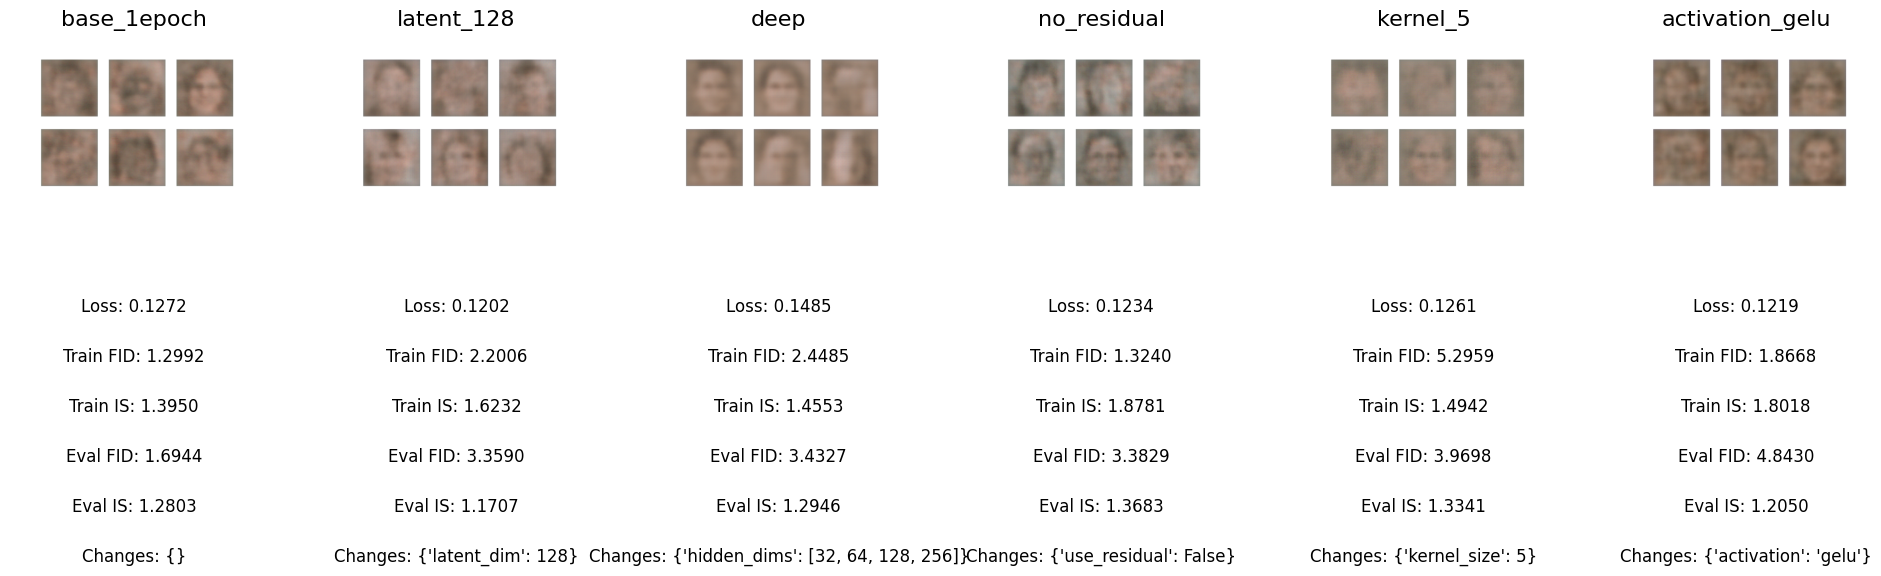

In [7]:
# 6.1) Ablation cards: name + pic + metrics + changes
def plot_ablation_cards(df, figsize=(24, 7)):
    import os

    n = len(df)
    fig, axes = plt.subplots(2, n, figsize=figsize)

    if n == 1:
        axes = [[axes[0]], [axes[1]]]

    for i, row in df.reset_index(drop=True).iterrows():
        # Top row: experiment name + image
        axes[0, i].set_title(row["experiment"], fontsize=16, pad=10)
        img_path = str(row["image_path"])

        try:
            if not os.path.exists(img_path):
                raise FileNotFoundError(img_path)
            img = plt.imread(img_path)
            axes[0, i].imshow(img)
        except Exception:
            axes[0, i].text(0.5, 0.5, "Image not found", ha="center", va="center")
        axes[0, i].axis("off")

        # Bottom row: metrics + changed params
        axes[1, i].axis("off")
        text = (
            f"Loss: {row['loss']:.4f}\n\n"
            f"Train FID: {row['train_fid']:.4f}\n\n"
            f"Train IS: {row['train_is']:.4f}\n\n"
            f"Eval FID: {row['eval_fid']:.4f}\n\n"
            f"Eval IS: {row['eval_is']:.4f}\n\n"
            f"Changes: {row['changed_params']}"
        )
        axes[1, i].text(
            0.5, 0.5,
            text,
            ha="center",
            va="center",
            fontsize=12,
            linespacing=1.5,
        )

    plt.subplots_adjust(hspace=0.35, wspace=0.3)
    plt.show()

plot_ablation_cards(ablation_table)

In [23]:
# 7) Final model train and model saving
final_config = {
    **base_config,
    "num_epochs": 100,
    "metric_interval": 5,
    "checkpoint_interval": 20,
}

checkpoint_model_dir = os.path.join(MODELS_DIR, "vae_checkpoints")
checkpoint_image_dir = os.path.join(VAE_IMAGE_DIR, "checkpoints")
os.makedirs(checkpoint_model_dir, exist_ok=True)
os.makedirs(checkpoint_image_dir, exist_ok=True)

final_model, final_loss_history, final_fid_history, final_is_history = train_vae_full(
    train_loader=train_loader,
    device=device,
    latent_dim=final_config["latent_dim"],
    hidden_dims=final_config["hidden_dims"],
    kernel_size=final_config["kernel_size"],
    stride=final_config["stride"],
    padding=final_config["padding"],
    use_residual=final_config["use_residual"],
    activation=final_config["activation"],
    lr=final_config["lr"],
    num_epochs=final_config["num_epochs"],
    metric_interval=final_config["metric_interval"],
    checkpoint_interval=final_config["checkpoint_interval"],
    model_save_dir=checkpoint_model_dir,
    image_save_dir=checkpoint_image_dir,
    model_prefix="final_vae",
)

save_path = os.path.join(MODELS_DIR, "final_vae.pth")
os.makedirs(os.path.dirname(save_path), exist_ok=True)
torch.save(final_model.state_dict(), save_path)

print("Final model saved to:", save_path)
print(f"Checkpoint models saved every {final_config['checkpoint_interval']} epochs to: {checkpoint_model_dir}")
print(f"Checkpoint images saved every {final_config['checkpoint_interval']} epochs to: {checkpoint_image_dir}")

Epoch 1/100:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch 1/100 | Loss: 0.1292 | FID: nan | IS: nan | Beta: 0.0005


Epoch 2/100:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch 2/100 | Loss: 0.0842 | FID: nan | IS: nan | Beta: 0.0010


Epoch 3/100:   0%|          | 0/141 [00:00<?, ?it/s]

...

Epoch 98/100 | Loss: 0.0840 | FID: nan | IS: nan | Beta: 0.0490


Epoch 99/100:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch 99/100 | Loss: 0.0841 | FID: nan | IS: nan | Beta: 0.0495


Epoch 100/100:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch 100/100 | Loss: 0.0842 | FID: 3.5533 | IS: 1.2612 | Beta: 0.0500
Checkpoint manifest saved to: /home/crisp/Projects/Gen AI - A1/models/vae_checkpoints/final_vae_checkpoint_manifest.csv
Final model saved to: /home/crisp/Projects/Gen AI - A1/models/final_vae.pth
Checkpoint models saved every 20 epochs to: /home/crisp/Projects/Gen AI - A1/models/vae_checkpoints
Checkpoint images saved every 20 epochs to: /home/crisp/Projects/Gen AI - A1/outputs/vae_images/checkpoints


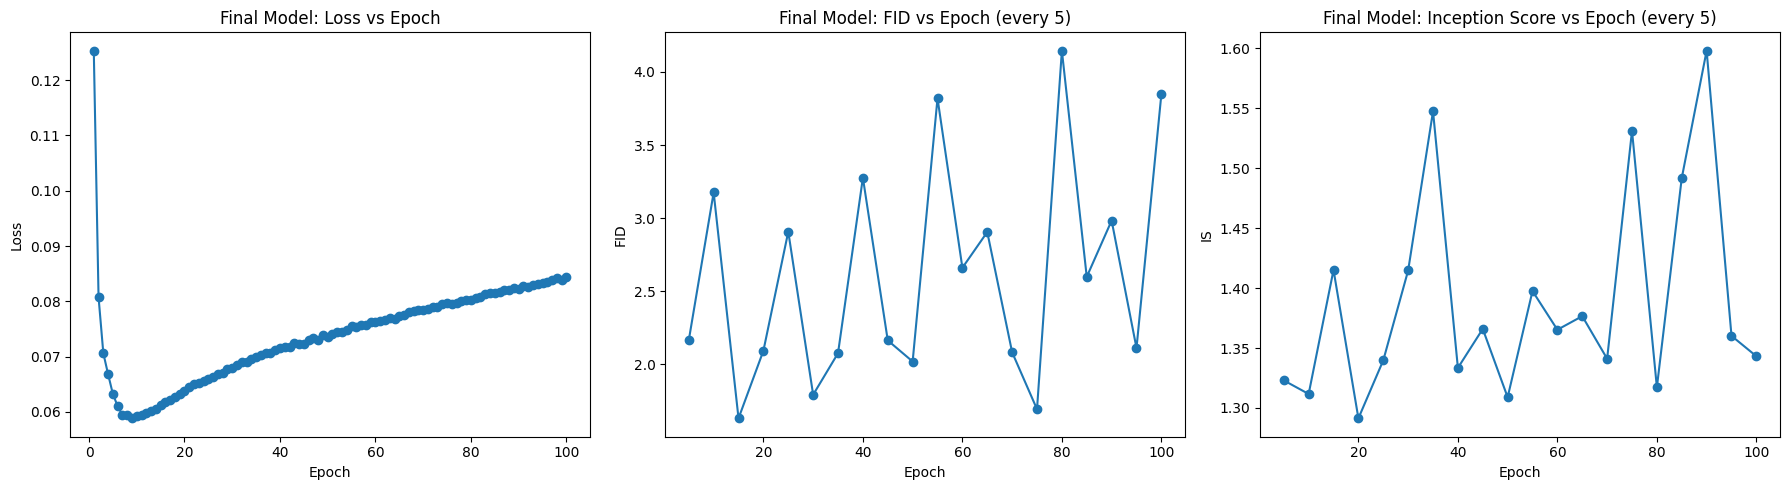

In [16]:
# 8) Metrics visualization
epochs = range(1, len(final_loss_history) + 1)

fid_epochs = [e for e, v in zip(epochs, final_fid_history) if pd.notna(v)]
fid_values = [v for v in final_fid_history if pd.notna(v)]

is_epochs = [e for e, v in zip(epochs, final_is_history) if pd.notna(v)]
is_values = [v for v in final_is_history if pd.notna(v)]

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, final_loss_history, marker="o")
plt.title("Final Model: Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 3, 2)
plt.plot(fid_epochs, fid_values, marker="o")
plt.title("Final Model: FID vs Epoch (every 5)")
plt.xlabel("Epoch")
plt.ylabel("FID")

plt.subplot(1, 3, 3)
plt.plot(is_epochs, is_values, marker="o")
plt.title("Final Model: Inception Score vs Epoch (every 5)")
plt.xlabel("Epoch")
plt.ylabel("IS")

plt.tight_layout()
plt.show()

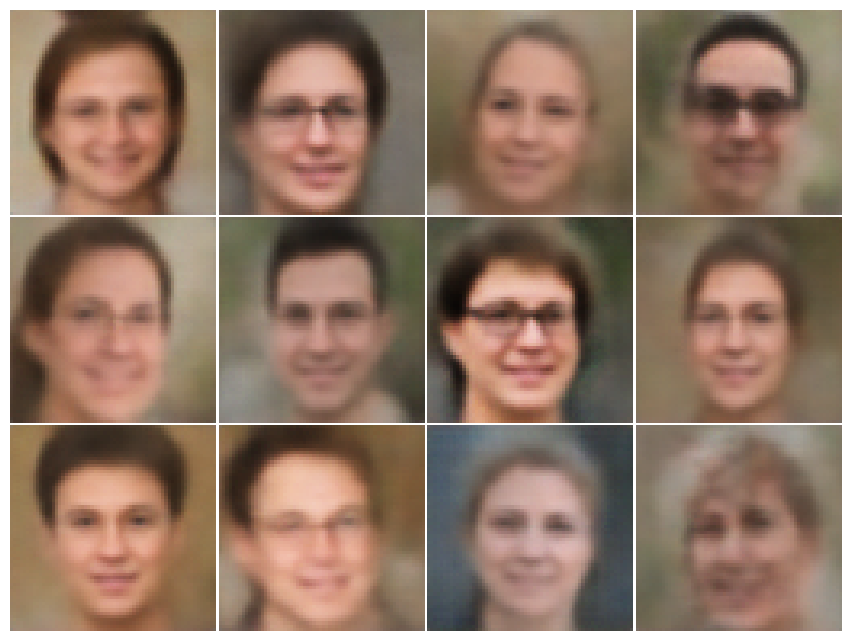

tensor([[[[0.6442, 0.6617, 0.6762,  ..., 0.6049, 0.6047, 0.6008],
          [0.6704, 0.6839, 0.6723,  ..., 0.6054, 0.6223, 0.6151],
          [0.6773, 0.6764, 0.6794,  ..., 0.6200, 0.6245, 0.6089],
          ...,
          [0.7193, 0.7112, 0.7346,  ..., 0.6364, 0.6416, 0.6247],
          [0.7280, 0.7402, 0.7249,  ..., 0.6433, 0.6387, 0.6432],
          [0.6550, 0.7280, 0.7140,  ..., 0.6467, 0.6363, 0.5960]],

         [[0.5773, 0.5855, 0.5927,  ..., 0.5284, 0.5333, 0.5159],
          [0.5887, 0.5811, 0.5790,  ..., 0.5440, 0.5375, 0.5377],
          [0.5891, 0.5889, 0.5755,  ..., 0.5450, 0.5423, 0.5434],
          ...,
          [0.6968, 0.6871, 0.6750,  ..., 0.5876, 0.5819, 0.5924],
          [0.6966, 0.6925, 0.6858,  ..., 0.5993, 0.5933, 0.5931],
          [0.6469, 0.6664, 0.6779,  ..., 0.5845, 0.5849, 0.5722]],

         [[0.4950, 0.4719, 0.4767,  ..., 0.4144, 0.4158, 0.4387],
          [0.4797, 0.4689, 0.4717,  ..., 0.4171, 0.4103, 0.4102],
          [0.4729, 0.4618, 0.4664,  ..., 0

In [14]:
# 9) Model loading for image generation
loaded_model = VAE(
    latent_dim=final_config["latent_dim"],
    hidden_dims=final_config["hidden_dims"],
    kernel_size=final_config["kernel_size"],
    stride=final_config["stride"],
    padding=final_config["padding"],
    use_residual=final_config["use_residual"],
    activation=final_config["activation"],
).to(device)

loaded_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "final_vae.pth"), map_location=device))

generate_vae_samples(
    model=loaded_model,
    num_samples=12,
    latent_dim=final_config["latent_dim"],
    device=device,
    save_path=os.path.join(OUTPUTS_DIR, "final_vae_samples.png"),
    show=True,
)